# Task 5 — Personal Loan Acceptance Prediction (Bank Marketing)

## Objective
Predict which customers are likely to accept a personal loan offer (target: `y` = yes/no).

## Dataset
Bank Marketing Dataset (UCI)

## What we will do
1. Load and inspect dataset
2. Basic EDA on **age**, **job**, **marital**
3. Build a baseline classifier (Logistic Regression)
4. Evaluate using Accuracy + Confusion Matrix (+ ROC-AUC if possible)
5. Extract business insights:
   - acceptance rate by job/marital group
   - top features (coefficients) that influence acceptance

## Run Instructions
- Run cells **top-to-bottom**
- Put dataset CSV in `data/` folder (preferred)
- If not found, notebook can auto-download a public mirror (`bank.csv`)

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import urllib.request
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# ----------------------------
# Repo path detection (prevents ../data issues)
# ----------------------------
def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start] + list(start.parents):
        if (p / ".git").exists() or (p / "data").exists():
            return p
    return start

ROOT = find_repo_root()
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs" / "task5_figures"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", ROOT)
print("Data dir :", DATA_DIR)
print("Out dir  :", OUT_DIR)

# ----------------------------
# Helpers
# ----------------------------
def save_fig(filename: str) -> None:
    try:
        out = OUT_DIR / filename
        plt.tight_layout()
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print("Saved:", out)
    except Exception as e:
        print("Note: could not save figure:", e)

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[ \-./]", "_", regex=True)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
    )
    return df

def read_csv_safely(path: Path) -> pd.DataFrame:
    # UCI bank dataset is often separated by ';'
    return pd.read_csv(path, sep=None, engine="python")

def download_bank_dataset(dest: Path) -> bool:
    """
    Downloads a public mirror of UCI Bank Marketing dataset.
    This is the smaller 'bank.csv' version (good for internship tasks).
    """
    urls = [
        "https://raw.githubusercontent.com/jbrownlee/Datasets/master/bank.csv",
        "https://raw.githubusercontent.com/selva86/datasets/master/Bank.csv",
    ]
    for url in urls:
        try:
            print("Trying download:", url)
            urllib.request.urlretrieve(url, dest)
            print("Downloaded to:", dest)
            return True
        except Exception as e:
            print("Download failed:", e)
    return False

Repo root: f:\coding\DevelopersHub-DS-Internship-Tasks
Data dir : f:\coding\DevelopersHub-DS-Internship-Tasks\data
Out dir  : f:\coding\DevelopersHub-DS-Internship-Tasks\outputs\task5_figures


In [2]:
# Search for common bank marketing filenames in data/
csv_files = sorted(DATA_DIR.glob("*.csv"))
print("CSV files in data/:", [f.name for f in csv_files])

candidate = None
keywords = ["bank", "marketing", "bank_full", "bank_additional", "bank-additional"]

for f in csv_files:
    name = f.name.lower()
    if any(k in name for k in keywords):
        candidate = f
        break

# If nothing found, try auto-download to data/bank.csv
if candidate is None:
    dest = DATA_DIR / "bank.csv"
    print("\nNo bank marketing CSV found in data/.")
    print("Auto-download attempt ->", dest.name)
    ok = download_bank_dataset(dest)
    if not ok:
        raise FileNotFoundError(
            "Bank marketing dataset not found and auto-download failed.\n"
            f"Fix: Place your CSV inside: {DATA_DIR}\n"
            "Example filenames: bank.csv, bank-full.csv, bank_marketing.csv"
        )
    candidate = dest

print("\nUsing dataset file:", candidate.name)
df_raw = read_csv_safely(candidate)
df = normalize_columns(df_raw)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

CSV files in data/: ['bank_marketing.csv', 'Churn_Modelling.csv', 'insurance_medical_cost.csv', 'Iris.csv', 'loan-prediction.csv']

Using dataset file: bank_marketing.csv
Shape: (5581, 18)
Columns: ['unnamed:_0', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


,unnamed:_0,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,0,41,services,married,unknown,no,88,yes,no,cellular,11,may,105,1,336,2,failure,no
1,1,56,technician,married,secondary,no,1938,no,yes,cellular,26,feb,229,1,192,4,success,yes
2,2,30,services,single,secondary,no,245,no,yes,cellular,8,jul,187,2,-1,0,unknown,no
3,3,34,management,single,tertiary,no,1396,yes,no,cellular,17,jul,630,1,-1,0,unknown,no
4,4,29,technician,single,secondary,no,-13,yes,no,cellular,14,may,512,3,-1,0,unknown,no


In [3]:
# Target is usually 'y' (yes/no)
if "y" not in df.columns:
    # some datasets might name it differently; try common alternatives
    alt = None
    for c in ["target", "subscribed", "deposit", "accepted", "response"]:
        if c in df.columns:
            alt = c
            break
    if alt is None:
        raise ValueError(
            "Target column not found. Expected 'y'.\n"
            f"Available columns: {df.columns.tolist()}"
        )
    else:
        df = df.rename(columns={alt: "y"})

print("Target distribution:")
display(df["y"].value_counts(dropna=False))

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(2)
display(missing_pct[missing_pct > 0].to_frame("missing_%"))

print("Duplicate rows:", int(df.duplicated().sum()))

Target distribution:


y
no     2959
yes    2622
Name: count, dtype: int64

,missing_%


Duplicate rows: 0


## EDA (Required)
We will explore:
- Age distribution
- Job distribution
- Marital status vs acceptance (`y`)

These plots help understand which groups are more likely to accept the offer.

Saved: f:\coding\DevelopersHub-DS-Internship-Tasks\outputs\task5_figures\eda_age_distribution.png


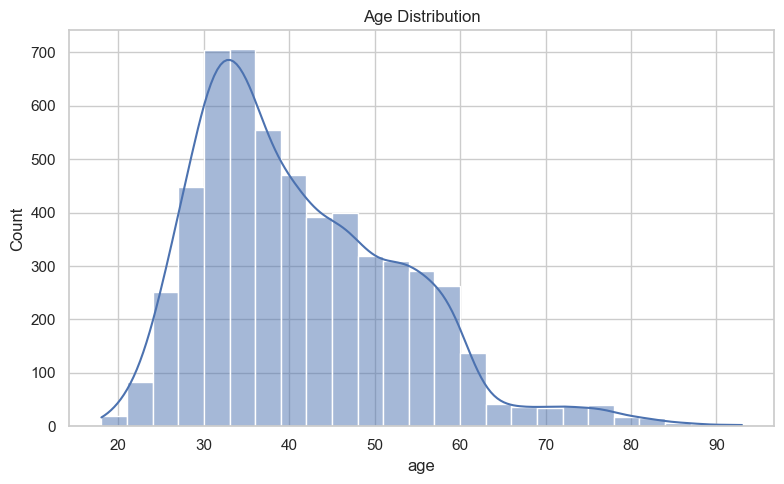

Saved: f:\coding\DevelopersHub-DS-Internship-Tasks\outputs\task5_figures\eda_job_distribution.png


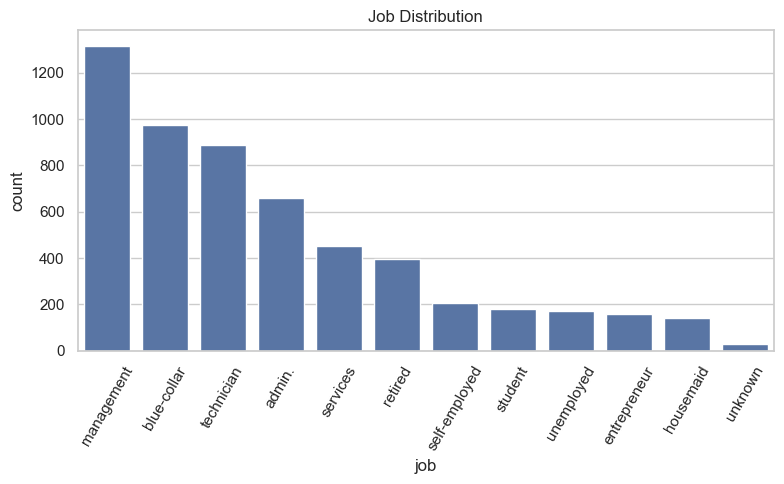

Saved: f:\coding\DevelopersHub-DS-Internship-Tasks\outputs\task5_figures\eda_marital_vs_y.png


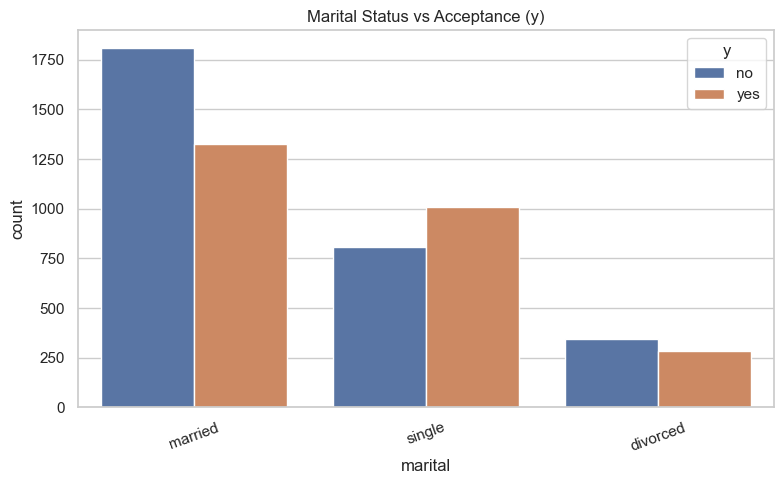

In [4]:
# Age distribution
if "age" in df.columns:
    ax = sns.histplot(df["age"].dropna(), bins=25, kde=True)
    ax.set_title("Age Distribution")
    save_fig("eda_age_distribution.png")
    plt.show()
else:
    print("Skipped: 'age' column not found.")

# Job distribution
if "job" in df.columns:
    order = df["job"].value_counts().index
    ax = sns.countplot(data=df, x="job", order=order)
    ax.set_title("Job Distribution")
    plt.xticks(rotation=60)
    save_fig("eda_job_distribution.png")
    plt.show()
else:
    print("Skipped: 'job' column not found.")

# Marital vs acceptance
if "marital" in df.columns:
    ax = sns.countplot(data=df, x="marital", hue="y")
    ax.set_title("Marital Status vs Acceptance (y)")
    plt.xticks(rotation=20)
    save_fig("eda_marital_vs_y.png")
    plt.show()
else:
    print("Skipped: 'marital' column not found.")

In [5]:
def acceptance_rate_by(col: str):
    if col not in df.columns:
        print(f"Skipped rate table: '{col}' not found.")
        return
    tmp = df.copy()
    # map y to 1/0 for rate
    y01 = tmp["y"].astype(str).str.lower().map({"yes": 1, "no": 0, "y": 1, "n": 0, "true": 1, "false": 0})
    if y01.isna().any():
        # fallback factorize
        y01 = pd.Series(pd.factorize(tmp["y"].astype(str))[0], index=tmp.index)

    out = (
        tmp.assign(y01=y01)
        .groupby(col)["y01"]
        .agg(["count", "mean"])
        .rename(columns={"count": "n", "mean": "accept_rate"})
        .sort_values("accept_rate", ascending=False)
    )
    display(out)

acceptance_rate_by("job")
acceptance_rate_by("marital")

,n,accept_rate
job,,
student,182,0.708791
retired,397,0.642317
unemployed,170,0.541176
management,1318,0.507587
self-employed,206,0.500000
admin.,661,0.462935
technician,887,0.457723
housemaid,143,0.419580
services,452,0.418142


,n,accept_rate
marital,,
single,1816,0.555617
divorced,631,0.453249
married,3134,0.423421


In [6]:
# Prepare X/y
X = df.drop(columns=["y"]).copy()
y_raw = df["y"].astype(str).str.strip().str.lower()

# Standard mapping for bank dataset
y = y_raw.map({"yes": 1, "no": 0, "y": 1, "n": 0, "true": 1, "false": 0})

if y.isna().any():
    # If dataset uses different labels, factorize safely
    codes, uniques = pd.factorize(df["y"].astype(str))
    y = pd.Series(codes, index=df.index)
    print("Target factorized. Classes:", list(uniques))

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=4000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y if y.nunique() == 2 else None
)

clf.fit(X_train, y_train)
print("Model trained successfully.")
print("Numeric cols:", len(num_cols), "| Categorical cols:", len(cat_cols))

Model trained successfully.
Numeric cols: 8 | Categorical cols: 9


Test Accuracy: 0.8183

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       592
           1       0.82      0.79      0.80       525

    accuracy                           0.82      1117
   macro avg       0.82      0.82      0.82      1117
weighted avg       0.82      0.82      0.82      1117

Saved: f:\coding\DevelopersHub-DS-Internship-Tasks\outputs\task5_figures\confusion_matrix.png


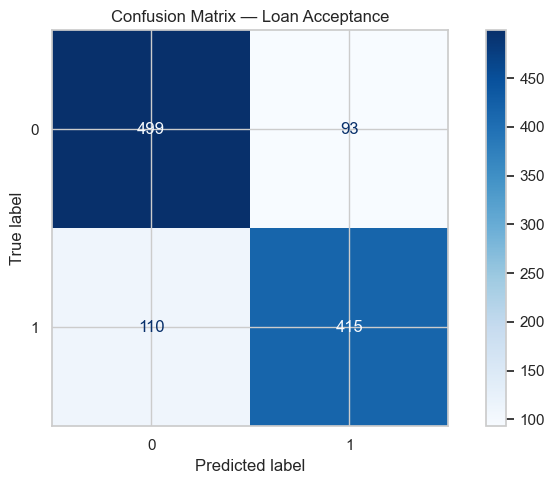

ROC-AUC: 0.8923


In [7]:
pred = clf.predict(X_test)

acc = accuracy_score(y_test, pred)
print("Test Accuracy:", round(acc, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Confusion Matrix — Loan Acceptance")
save_fig("confusion_matrix.png")
plt.show()

# ROC-AUC (only if binary and predict_proba available)
if hasattr(clf, "predict_proba") and y.nunique() == 2:
    proba = clf.predict_proba(X_test)[:, 1]
    print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))

In [8]:
if y.nunique() == 2:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")
    print("CV Accuracy mean:", round(scores.mean(), 4), "| std:", round(scores.std(), 4))
else:
    print("CV skipped: target is not binary.")

CV Accuracy mean: 0.814 | std: 0.0054


Top positive drivers (increase acceptance probability):


,feature,coef
0,poutcome_success,1.635843
1,month_mar,1.467905
2,month_oct,0.915084
3,month_sep,0.775899
4,month_dec,0.547966
5,month_jun,0.505638
6,contact_cellular,0.500982
7,job_student,0.449346
8,job_retired,0.435487
9,contact_telephone,0.292032


Top negative drivers (decrease acceptance probability):


,feature,coef
37,loan_yes,-0.277150
38,marital_married,-0.315857
39,poutcome_other,-0.354393
40,default_yes,-0.361633
41,job_blue-collar,-0.378438
42,housing_yes,-0.430474
43,job_entrepreneur,-0.451835
44,poutcome_failure,-0.515332
45,month_may,-0.677997
46,month_aug,-0.777015


Saved: f:\coding\DevelopersHub-DS-Internship-Tasks\outputs\task5_figures\top_positive_coefficients.png


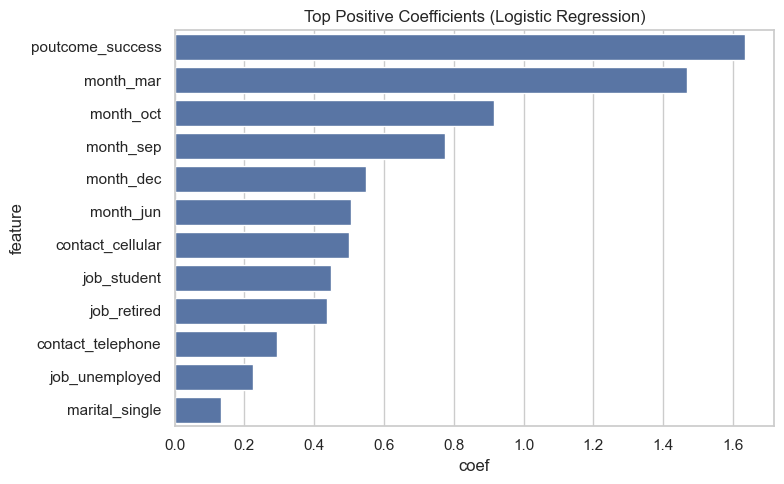

In [9]:
# Extract feature names after OneHotEncoding to interpret coefficients
try:
    ohe = clf.named_steps["preprocess"].named_transformers_["cat"].named_steps["ohe"]
    cat_feature_names = ohe.get_feature_names_out(cat_cols)
    feature_names = np.array(num_cols + list(cat_feature_names))

    coefs = clf.named_steps["model"].coef_.ravel()
    coef_df = (pd.DataFrame({"feature": feature_names, "coef": coefs})
               .sort_values("coef", ascending=False)
               .reset_index(drop=True))

    print("Top positive drivers (increase acceptance probability):")
    display(coef_df.head(15))

    print("Top negative drivers (decrease acceptance probability):")
    display(coef_df.tail(15))

    ax = sns.barplot(data=coef_df.head(12), x="coef", y="feature")
    ax.set_title("Top Positive Coefficients (Logistic Regression)")
    save_fig("top_positive_coefficients.png")
    plt.show()

except Exception as e:
    print("Interpretation skipped. Reason:", e)

## Conclusion
- Summarize model performance (Accuracy + Confusion Matrix, optionally ROC-AUC).
- Mention which customer groups show higher acceptance rate (from rate tables).
- Mention top features affecting acceptance (from coefficients).

## Improvements
- Try Decision Tree / RandomForest and compare results.
- Tune hyperparameters and decision threshold.
- Handle class imbalance if acceptance rate is low.